# Sensitivity Analysis of ODE Market-Making Model

Global sensitivity analysis (Sobol indices) and forward uncertainty quantification
for the 3-currency (USD, EUR, GBP) ODE approximation.

See `notes/sensitivity-analysis/three_currency_setup.md` for methodology.

In [66]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
from tqdm import tqdm
import time

from src import build_paper_example_params, restrict_currencies, run_multicurrency_mm
from src.model import ModelParams, PairParams, TierParams, BP
from src.hamiltonian import logistic_f
from src.sobol import saltelli_sample, evaluate_saltelli_samples, compute_sobol_indices

## Parameter setup

20 parameters varied over uniform ranges around the paper's nominal values (Table 1).

- 5 global parameters (volatilities, correlation, risk aversion, arrival rate scale)
- 5 per pair (demand curve shape and execution cost) for EUR/USD, GBP/USD, EUR/GBP

In [68]:
PARAM_NAMES = [
    # Global (0-4)
    r"$\sigma_{\mathrm{EUR}}$", r"$\sigma_{\mathrm{GBP}}$", r"$\rho$",
    r"$\gamma$", r"$\lambda_{\mathrm{scale}}$",
    # EUR/USD (5-9)
    r"$\alpha_1^{\mathrm{EU}}$", r"$\alpha_2^{\mathrm{EU}}$",
    r"$\beta_1^{\mathrm{EU}}$", r"$\beta_2^{\mathrm{EU}}$", r"$\eta^{\mathrm{EU}}$",
    # GBP/USD (10-14)
    r"$\alpha_1^{\mathrm{GU}}$", r"$\alpha_2^{\mathrm{GU}}$",
    r"$\beta_1^{\mathrm{GU}}$", r"$\beta_2^{\mathrm{GU}}$", r"$\eta^{\mathrm{GU}}$",
    # EUR/GBP (15-19)
    r"$\alpha_1^{\mathrm{EG}}$", r"$\alpha_2^{\mathrm{EG}}$",
    r"$\beta_1^{\mathrm{EG}}$", r"$\beta_2^{\mathrm{EG}}$", r"$\eta^{\mathrm{EG}}$",
]

PARAM_LABELS = [
    "sigma_EUR", "sigma_GBP", "rho", "gamma", "lambda_scale",
    "alpha_1 EU", "alpha_2 EU", "beta_1 EU", "beta_2 EU", "eta EU",
    "alpha_1 GU", "alpha_2 GU", "beta_1 GU", "beta_2 GU", "eta GU",
    "alpha_1 EG", "alpha_2 EG", "beta_1 EG", "beta_2 EG", "eta EG",
]

# Nominal values in human-readable units
# sigma: bps, gamma: 1/M$, lambda_scale: multiplier,
# alpha: dimensionless, beta: 1/bps (paper units), eta: bps
NOMINAL = np.array([
    80.0, 70.0, 0.6, 20.0, 1.0,                         # global
    -1.9, -0.3, 11.0, 3.5, 1e-5,                         # EUR/USD
    -1.4, 0.0, 5.5, 2.0, 1.5e-5,                         # GBP/USD
    -0.5, 0.5, 3.5, 2.5, 3e-5,                           # EUR/GBP
])

RANGES = np.array([
    [56.0, 104.0],       # sigma_EUR (bps), +-30%
    [49.0, 91.0],        # sigma_GBP (bps), +-30%
    [0.3, 0.9],          # rho, +-50%
    [10.0, 40.0],        # gamma, +-50%
    [0.5, 1.5],          # lambda_scale, +-50%
    [-2.5, -1.3],        # alpha_1 EU, +-30%
    [-0.9, 0.3],         # alpha_2 EU, +-100%
    [7.7, 14.3],         # beta_1 EU (1/bps), +-30%
    [2.45, 4.55],        # beta_2 EU (1/bps), +-30%
    [0.5e-5, 2.0e-5],   # eta EU (bps), +-50%
    [-2.0, -0.8],        # alpha_1 GU
    [-0.6, 0.6],         # alpha_2 GU
    [3.85, 7.15],        # beta_1 GU (1/bps), +-30%
    [1.4, 2.6],          # beta_2 GU (1/bps), +-30%
    [0.75e-5, 3.0e-5],  # eta GU (bps), +-50%
    [-1.1, 0.1],         # alpha_1 EG
    [-0.1, 1.1],         # alpha_2 EG
    [2.45, 4.55],        # beta_1 EG (1/bps), +-30%
    [1.75, 3.25],        # beta_2 EG (1/bps), +-30%
    [1.5e-5, 6.0e-5],   # eta EG (bps), +-50%
])

QOI_NAMES = [
    # Set A: quoting policy
    r"Tier spread diff [bps]",
    r"Own-inventory skew [bps]",
    r"Cross-inventory skew [bps]",
    # Set B: hedging and economics
    r"Own-pair hedge rate [M$/day]",
    r"Cross-hedge momentum [decimal]",
    r"Net revenue [$/day]",
]

N_PARAMS = len(PARAM_NAMES)
N_QOIS = len(QOI_NAMES)

PARAM_GROUPS = ["Global"] * 5 + ["EUR/USD"] * 5 + ["GBP/USD"] * 5 + ["EUR/GBP"] * 5

GROUP_COLORS = {
    "Global":  "#2c7bb6",
    "EUR/USD": "#d7191c",
    "GBP/USD": "#fdae61",
    "EUR/GBP": "#1a9641",
}

print(f"{N_PARAMS} parameters, {N_QOIS} QoIs")
print(f"Saltelli evaluations for N=10000: {10000 * (N_PARAMS + 2):,}")

20 parameters, 6 QoIs
Saltelli evaluations for N=10000: 220,000


## Model evaluation

Map the 20-dimensional parameter vector to 6 scalar quantities of interest
via the Riccati ODE solver.

**Set A (quoting policy):**
1. Tier spread differential on EUR/USD at flat inventory
2. Own-inventory skew: EUR/USD markup shift when holding 10 M$ EUR
3. Cross-inventory skew: EUR/USD markup shift when holding 10 M$ GBP

**Set B (hedging and economics):**
4. Own-pair hedge rate: EUR/USD hedge at 10 M$ EUR
5. Cross-hedge momentum: value function gradient projected onto EUR/GBP direction at 10 M$ EUR
6. Net revenue: total revenue minus total hedging cost at 10 M$ EUR

In [69]:
# Cache base parameters to avoid rebuilding every call
_base = restrict_currencies(build_paper_example_params(), ["USD", "EUR", "GBP"])
_base_eu = _base.pairs[("EUR", "USD")]
_base_gu = _base.pairs[("GBP", "USD")]
_base_eg = _base.pairs[("EUR", "GBP")]


def build_modified_params(params):
    """Build 3-currency (USD, EUR, GBP) ModelParams from 20-element parameter vector.

    Parameters in human-readable units (sigma in bps, beta in 1/bps, eta in bps).
    Converted to internal units (decimal) inside this function.
    """
    (sigma_eur, sigma_gbp, rho, gamma, lam_scale,
     a1_eu, a2_eu, b1_eu, b2_eu, eta_eu,
     a1_gu, a2_gu, b1_gu, b2_gu, eta_gu,
     a1_eg, a2_eg, b1_eg, b2_eg, eta_eg) = params

    # EUR/USD pair
    tiers_eu = [
        TierParams(alpha=a1_eu, beta=b1_eu * 1e4),
        TierParams(alpha=a2_eu, beta=b2_eu * 1e4),
    ]
    pp_eu = PairParams(
        pair=("EUR", "USD"),
        sizes_musd=_base_eu.sizes_musd,
        lambdas_per_day=_base_eu.lambdas_per_day * lam_scale,
        tiers=tiers_eu,
        psi=_base_eu.psi,
        eta=eta_eu * BP,
    )

    # GBP/USD pair
    tiers_gu = [
        TierParams(alpha=a1_gu, beta=b1_gu * 1e4),
        TierParams(alpha=a2_gu, beta=b2_gu * 1e4),
    ]
    pp_gu = PairParams(
        pair=("GBP", "USD"),
        sizes_musd=_base_gu.sizes_musd,
        lambdas_per_day=_base_gu.lambdas_per_day * lam_scale,
        tiers=tiers_gu,
        psi=_base_gu.psi,
        eta=eta_gu * BP,
    )

    # EUR/GBP pair
    tiers_eg = [
        TierParams(alpha=a1_eg, beta=b1_eg * 1e4),
        TierParams(alpha=a2_eg, beta=b2_eg * 1e4),
    ]
    pp_eg = PairParams(
        pair=("EUR", "GBP"),
        sizes_musd=_base_eg.sizes_musd,
        lambdas_per_day=_base_eg.lambdas_per_day * lam_scale,
        tiers=tiers_eg,
        psi=_base_eg.psi,
        eta=eta_eg * BP,
    )

    return ModelParams(
        currencies=["USD", "EUR", "GBP"],
        ref_ccy="USD",
        sigma={"USD": 0.0, "EUR": sigma_eur * BP, "GBP": sigma_gbp * BP},
        corr={("EUR", "GBP"): rho},
        k=_base.k,
        mu={"USD": 0.0, "EUR": 0.0, "GBP": 0.0},
        gamma=gamma,
        kappa=np.zeros((3, 3)),
        T_days=_base.T_days,
        pairs={("EUR", "USD"): pp_eu, ("GBP", "USD"): pp_gu, ("EUR", "GBP"): pp_eg},
    )


def _revenue_rate(mp, res, y):
    """Instantaneous expected revenue rate ($/day) at inventory y.

    R = sum over all pairs, directions, tiers, sizes of: lambda_j * f(delta*) * delta* * z_j
    Converted from M$/day to $/day (* 1e6).
    """
    revenue = 0.0
    for (a, b), pp in mp.pairs.items():
        for ccy_pay, ccy_sell in [(a, b), (b, a)]:
            for t_idx, tier in enumerate(pp.tiers):
                for z, lam in zip(pp.sizes_musd, pp.lambdas_per_day):
                    delta = res.markup(t_idx, ccy_pay, ccy_sell, z, y)
                    f = logistic_f(delta, tier.alpha, tier.beta)
                    revenue += lam * f * delta * z
    return revenue * 1e6


def evaluate_qois(params):
    """Solve ODE and return 6 QoIs for the 3-currency model.

    Set A (quoting):  [tier spread diff (bps), own-inv skew (bps), cross-inv skew (bps)]
    Set B (hedging):  [own-pair hedge (M$/day), cross-hedge momentum (decimal), net revenue ($/day)]
    """
    mp = build_modified_params(params)
    res = run_multicurrency_mm(mp, n_steps=500)

    y_flat = np.zeros(3)
    y_long_eur = np.array([0.0, 10.0, 0.0])
    y_long_gbp = np.array([0.0, 0.0, 10.0])

    # --- Set A: quoting policy ---
    # QoI 1: tier spread differential (tier 1 - tier 2) at y=0, EUR/USD, z=1 M$
    delta_t1 = res.markup(0, "EUR", "USD", 1.0, y_flat)
    delta_t2 = res.markup(1, "EUR", "USD", 1.0, y_flat)
    tier_diff = (delta_t1 - delta_t2) / BP

    # QoI 2: own-inventory skew (EUR/USD, tier 1, z=1) — EUR inventory effect
    delta_t1_long_eur = res.markup(0, "EUR", "USD", 1.0, y_long_eur)
    own_skew = (delta_t1_long_eur - delta_t1) / BP

    # QoI 3: cross-inventory skew (EUR/USD, tier 1, z=1) — GBP inventory effect
    delta_t1_long_gbp = res.markup(0, "EUR", "USD", 1.0, y_long_gbp)
    cross_skew = (delta_t1_long_gbp - delta_t1) / BP

    # --- Set B: hedging and economics ---
    # QoI 4: own-pair hedge rate (EUR/USD at y_long_eur)
    xi_own = res.hedge_rate("EUR", "USD", y_long_eur)

    # QoI 5: cross-pair hedging momentum (EUR/GBP at y_long_eur)
    # The value function gradient projected onto the EUR/GBP direction,
    # i.e. the "desire to cross-hedge" before the dead zone clips it.
    # p = -(2*A0*y + B0) . d_{EUR/GBP}
    ccy = mp.currencies
    i_eur, i_gbp = ccy.index("EUR"), ccy.index("GBP")
    d_eg = np.zeros(3)
    d_eg[i_eur] = 1.0
    d_eg[i_gbp] = -1.0
    AyB = 2.0 * res.A0 @ y_long_eur + res.B0
    p_cross = -(AyB @ d_eg)

    # QoI 6: net revenue at y_long_eur
    R_long = _revenue_rate(mp, res, y_long_eur)
    L_total = 0.0
    for (a, b), pp in mp.pairs.items():
        xi = res.hedge_rate(a, b, y_long_eur)
        L_total += (pp.psi * abs(xi) + pp.eta * xi**2) * 1e6
    net_revenue = R_long - L_total

    return np.array([tier_diff, own_skew, cross_skew, xi_own, p_cross, net_revenue])

## Sanity check

Verify the model evaluation at nominal parameters. Compare n_steps=500 vs 2000 to confirm
the ODE discretization error is negligible. Time a single evaluation to estimate total Sobol runtime.

In [70]:
# Evaluate at nominal with n_steps=500 (default) and n_steps=2000 (high accuracy)
qoi_500 = evaluate_qois(NOMINAL)

# High-accuracy reference
mp_nom = build_modified_params(NOMINAL)
res_2000 = run_multicurrency_mm(mp_nom, n_steps=2000)

y_flat = np.zeros(3)
y_long_eur = np.array([0.0, 10.0, 0.0])
y_long_gbp = np.array([0.0, 0.0, 10.0])

d_t1 = res_2000.markup(0, "EUR", "USD", 1.0, y_flat)
d_t2 = res_2000.markup(1, "EUR", "USD", 1.0, y_flat)
d_t1_long_eur = res_2000.markup(0, "EUR", "USD", 1.0, y_long_eur)
d_t1_long_gbp = res_2000.markup(0, "EUR", "USD", 1.0, y_long_gbp)
xi_own_2k = res_2000.hedge_rate("EUR", "USD", y_long_eur)

# Cross-hedge momentum at n_steps=2000
ccy = mp_nom.currencies
i_eur, i_gbp = ccy.index("EUR"), ccy.index("GBP")
d_eg = np.zeros(3)
d_eg[i_eur] = 1.0
d_eg[i_gbp] = -1.0
AyB_2k = 2.0 * res_2000.A0 @ y_long_eur + res_2000.B0
p_cross_2k = -(AyB_2k @ d_eg)

R_long_2k = _revenue_rate(mp_nom, res_2000, y_long_eur)
L_total_2k = 0.0
for (a, b), pp in mp_nom.pairs.items():
    xi = res_2000.hedge_rate(a, b, y_long_eur)
    L_total_2k += (pp.psi * abs(xi) + pp.eta * xi**2) * 1e6

qoi_2000 = np.array([
    (d_t1 - d_t2) / BP,
    (d_t1_long_eur - d_t1) / BP,
    (d_t1_long_gbp - d_t1) / BP,
    xi_own_2k,
    p_cross_2k,
    R_long_2k - L_total_2k,
])

print("QoIs at nominal parameter values:")
print(f"{'QoI':>40s}  {'n=500':>12s}  {'n=2000':>12s}  {'rel err':>10s}")
for name, v500, v2000 in zip(QOI_NAMES, qoi_500, qoi_2000):
    err = abs(v500 - v2000) / (abs(v2000) + 1e-30)
    print(f"{name:>40s}  {v500:12.6g}  {v2000:12.6g}  {err:10.2e}")

# Time a single evaluation
t0 = time.time()
for _ in range(100):
    evaluate_qois(NOMINAL)
t_per = (time.time() - t0) / 100
print(f"\nTime per evaluation: {t_per*1000:.1f} ms")
print(f"Estimated time for N=10000 Sobol: {t_per * 10000 * (N_PARAMS + 2) / 60:.1f} min")

QoIs at nominal parameter values:
                                     QoI         n=500        n=2000     rel err
                  Tier spread diff [bps]     -0.210402     -0.210402    2.64e-16
                Own-inventory skew [bps]       0.12099       0.12099    3.75e-14
              Cross-inventory skew [bps]     0.0464844     0.0464844    6.77e-13
            Own-pair hedge rate [M$/day]      -1568.37      -1568.37    1.77e-13
          Cross-hedge momentum [decimal]  -1.02033e-05  -1.02033e-05    5.31e-13
                     Net revenue [$/day]        507732        507732    1.43e-13

Time per evaluation: 9.1 ms
Estimated time for N=10000 Sobol: 33.3 min


## Sobol computation

Global sensitivity analysis using Saltelli's Monte Carlo estimator.

- First-order $S_i$: fraction of output variance due to parameter $i$ alone (Saltelli 2010)
- Total-effect $S_{Ti}$: includes all interactions involving parameter $i$ (Jansen 1999)

Total model evaluations: $N \times (k + 2) = 10{,}000 \times 22 = 220{,}000$.

**To rerun from scratch:** execute the next two cells (~30 min). The second cell saves all results
to `data/sensitivity_analysis/`.

**To use saved results:** skip the next two cells and run the cell under "Load saved results" instead.

In [71]:
N_SOBOL = 10_000

print(f"Sobol analysis: N={N_SOBOL}, k={N_PARAMS}, total evals={N_SOBOL*(N_PARAMS+2):,}")
A, B = saltelli_sample(N_SOBOL, RANGES, seed=42)
f_A, f_B, f_C = evaluate_saltelli_samples(evaluate_qois, A, B)

Sobol analysis: N=10000, k=20, total evals=220,000


Saltelli evaluations: 100%|██████████| 220000/220000 [35:25<00:00, 103.51it/s]


In [73]:
S, S_T = compute_sobol_indices(f_A, f_B, f_C)
fwd_qois = np.concatenate([f_A, f_B], axis=0)
nominal_qois = evaluate_qois(NOMINAL)

# Save all results
save_dir = "data/sensitivity_analysis"
os.makedirs(save_dir, exist_ok=True)

np.savez(os.path.join(save_dir, "saltelli_evaluations.npz"),
         f_A=f_A, f_B=f_B, f_C=f_C, A_samples=A, B_samples=B)
np.savez(os.path.join(save_dir, "sobol_indices.npz"), S=S, S_T=S_T)
np.savez(os.path.join(save_dir, "forward_uq.npz"),
         fwd_qois=fwd_qois, nominal_qois=nominal_qois)

meta = {
    "N_SOBOL": int(N_SOBOL), "N_PARAMS": int(N_PARAMS), "N_QOIS": int(N_QOIS),
    "PARAM_LABELS": PARAM_LABELS, "QOI_NAMES": QOI_NAMES,
    "NOMINAL": NOMINAL.tolist(), "RANGES": RANGES.tolist(),
    "PARAM_GROUPS": PARAM_GROUPS, "seed": 42,
}
with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved to {save_dir}/")
for fn in sorted(os.listdir(save_dir)):
    size = os.path.getsize(os.path.join(save_dir, fn))
    print(f"  {fn}: {size / 1e6:.1f} MB")

Saved to data/sensitivity_analysis/
  forward_uq.npz: 1.0 MB
  metadata.json: 0.0 MB
  saltelli_evaluations.npz: 13.8 MB
  sobol_indices.npz: 0.0 MB


### Load saved results

Run this cell instead of the two above to skip the ~30 min computation.
Loads the Sobol indices, forward UQ samples, and nominal QoIs from `data/sensitivity_analysis/`.

In [74]:
save_dir = "data/sensitivity_analysis"

d = np.load(os.path.join(save_dir, "saltelli_evaluations.npz"))
f_A, f_B, f_C = d["f_A"], d["f_B"], d["f_C"]

d = np.load(os.path.join(save_dir, "sobol_indices.npz"))
S, S_T = d["S"], d["S_T"]

d = np.load(os.path.join(save_dir, "forward_uq.npz"))
fwd_qois, nominal_qois = d["fwd_qois"], d["nominal_qois"]

N_SOBOL = f_A.shape[0]
N_FWD = fwd_qois.shape[0]
print(f"Loaded: N_SOBOL={N_SOBOL:,}, N_FWD={N_FWD:,}, S shape={S.shape}")

Loaded: N_SOBOL=10,000, N_FWD=20,000, S shape=(20, 6)


## Results: Sobol indices

In [75]:
# Print Sobol indices grouped by parameter category
for label, indices in [("First-order S_i", S), ("Total-effect S_Ti", S_T)]:
    print(f"\n{label}:")
    header = "  ".join(f"{'QoI '+str(q+1):>8s}" for q in range(N_QOIS))
    print(f"{'':>15s}  {header}")

    prev_group = None
    for i in range(N_PARAMS):
        group = PARAM_GROUPS[i]
        if group != prev_group:
            print(f"  --- {group} ---")
            prev_group = group
        vals = "  ".join(f"{indices[i, q]:8.3f}" for q in range(N_QOIS))
        print(f"{PARAM_LABELS[i]:>15s}  {vals}")

    sums = "  ".join(f"{indices.sum(axis=0)[q]:8.3f}" for q in range(N_QOIS))
    print(f"{'SUM':>15s}  {sums}")

print(f"\nSum of S_i:  {S.sum(axis=0)}")
print(f"Sum of S_Ti: {S_T.sum(axis=0)}")


First-order S_i:
                    QoI 1     QoI 2     QoI 3     QoI 4     QoI 5     QoI 6
  --- Global ---
      sigma_EUR     0.000     0.346     0.030     0.232     0.360     0.028
      sigma_GBP    -0.000     0.001     0.086     0.000     0.058    -0.000
            rho     0.000     0.002     0.387     0.001     0.246    -0.000
          gamma    -0.000     0.316     0.196     0.209     0.137     0.063
   lambda_scale    -0.000     0.261     0.150     0.193     0.114     0.775
  --- EUR/USD ---
     alpha_1 EU     0.039     0.006     0.014     0.007     0.006     0.004
     alpha_2 EU     0.106    -0.000    -0.000     0.000     0.000     0.042
      beta_1 EU     0.165     0.004     0.002     0.025     0.017     0.002
      beta_2 EU     0.719     0.004     0.001     0.003     0.002     0.017
         eta EU     0.000     0.000     0.000     0.145     0.000     0.007
  --- GBP/USD ---
     alpha_1 GU     0.000     0.000     0.001    -0.000    -0.000     0.012
     alpha_2 GU  

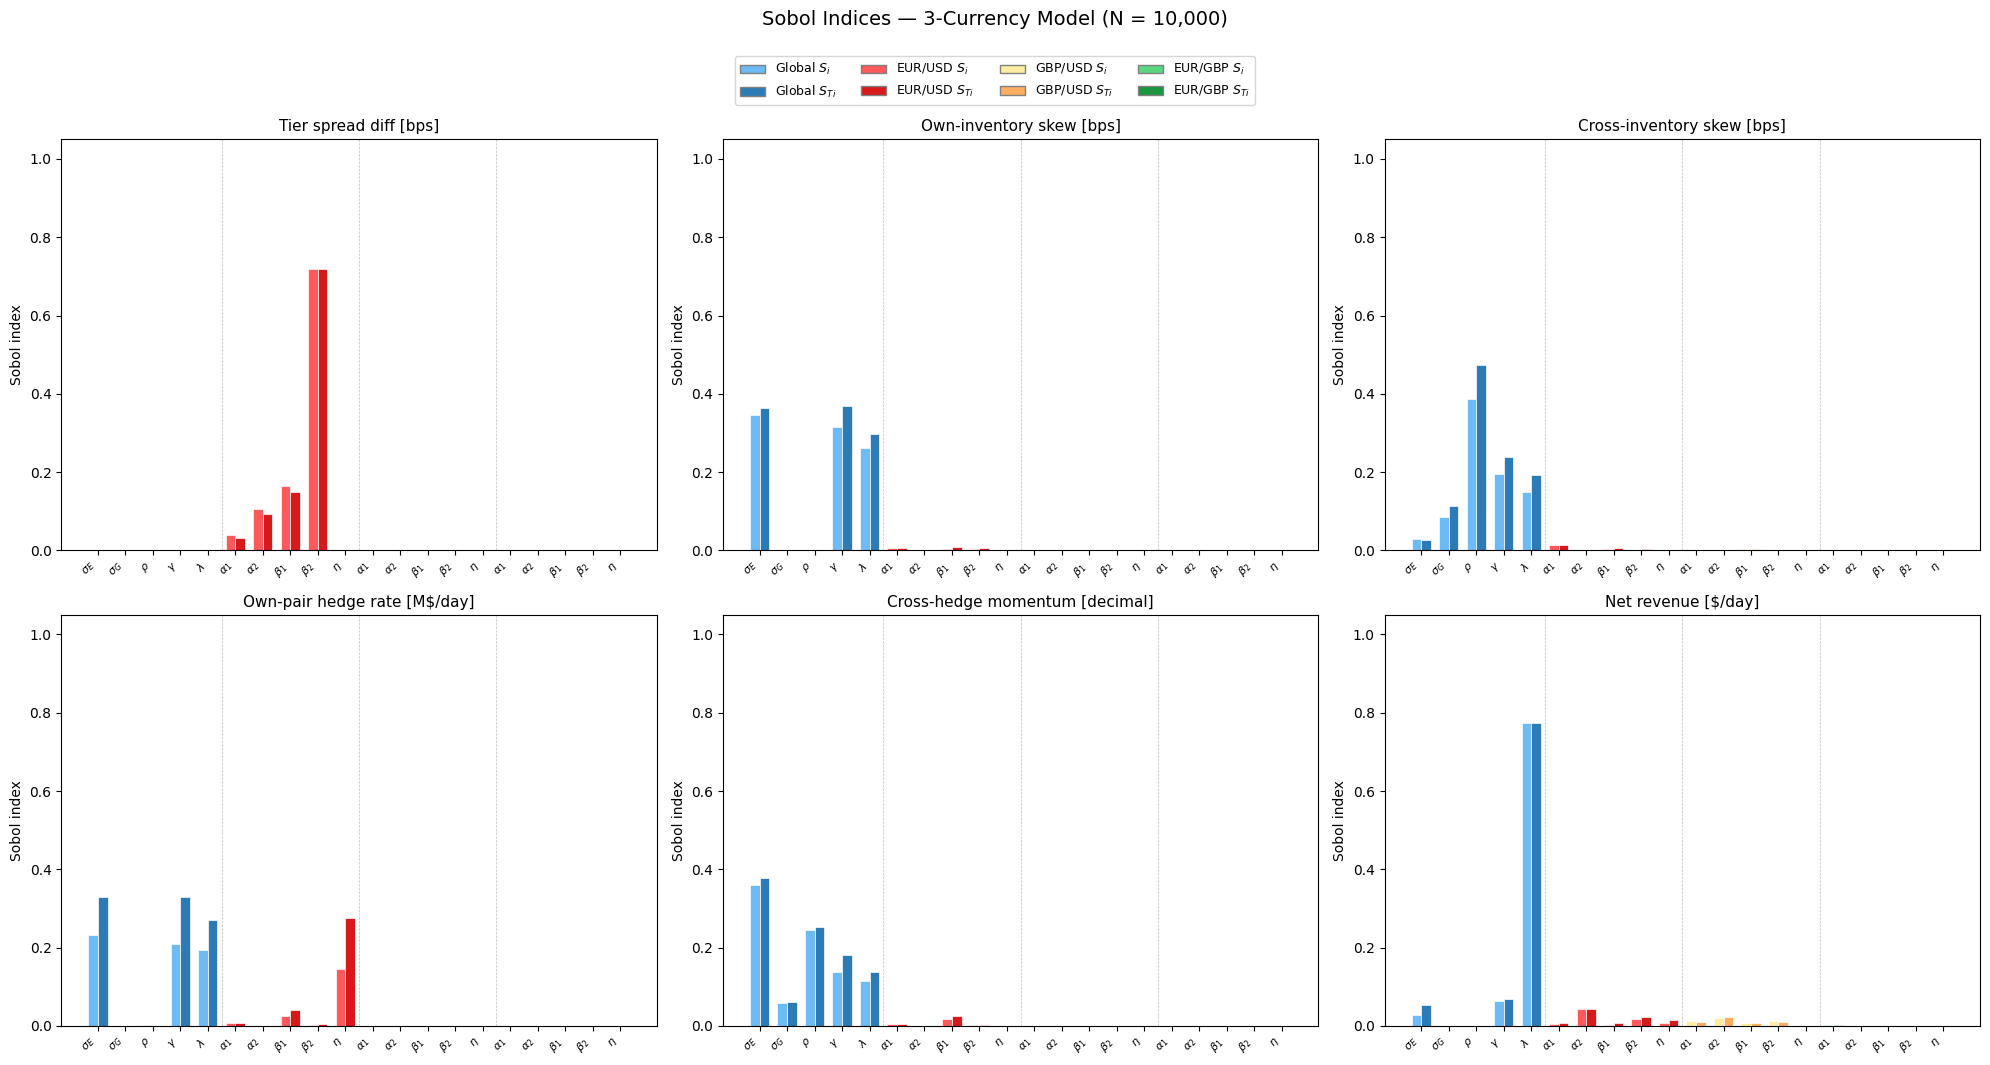

In [76]:
SHORT_LABELS = [
    r"$\sigma_E$", r"$\sigma_G$", r"$\rho$", r"$\gamma$", r"$\lambda$",
    r"$\alpha_1$", r"$\alpha_2$", r"$\beta_1$", r"$\beta_2$", r"$\eta$",
    r"$\alpha_1$", r"$\alpha_2$", r"$\beta_1$", r"$\beta_2$", r"$\eta$",
    r"$\alpha_1$", r"$\alpha_2$", r"$\beta_1$", r"$\beta_2$", r"$\eta$",
]

x = np.arange(N_PARAMS)
width = 0.35

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for q in range(N_QOIS):
    row = q // 3
    col = q % 3
    ax = axes[row, col]

    for i in range(N_PARAMS):
        base_color = GROUP_COLORS[PARAM_GROUPS[i]]
        rgb = mcolors.to_rgb(base_color)
        light = tuple(min(1.0, c + 0.25) for c in rgb)

        ax.bar(x[i] - width/2, S[i, q], width, color=light, edgecolor='white', linewidth=0.5)
        ax.bar(x[i] + width/2, S_T[i, q], width, color=rgb, edgecolor='white', linewidth=0.5)

    ax.set_ylabel('Sobol index')
    ax.set_title(QOI_NAMES[q], fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(SHORT_LABELS, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)

    for boundary in [4.5, 9.5, 14.5]:
        ax.axvline(boundary, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

legend_handles = []
for group, color in GROUP_COLORS.items():
    rgb = mcolors.to_rgb(color)
    light = tuple(min(1.0, c + 0.25) for c in rgb)
    legend_handles.append(Patch(facecolor=light, edgecolor='grey', label=f'{group} $S_i$'))
    legend_handles.append(Patch(facecolor=rgb, edgecolor='grey', label=f'{group} $S_{{Ti}}$'))

fig.legend(handles=legend_handles, loc='upper center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f'Sobol Indices — 3-Currency Model (N = {N_SOBOL:,})', fontsize=14, y=1.06)
plt.tight_layout()
plt.savefig('report/figures/fig_sa_sobol.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Forward Uncertainty Quantification

Propagate parameter uncertainty through the ODE model and estimate the distribution
of each quantity of interest via kernel density estimation. Reuses the A and B
evaluation samples from the Sobol computation (20,000 points).

In [77]:
N_FWD = fwd_qois.shape[0]
print(f"Forward UQ using {N_FWD:,} samples")

print(f"\n{'QoI':>40s}  {'mean':>10s}  {'std':>10s}  {'5%':>10s}  {'95%':>10s}  {'nominal':>10s}")
for q in range(N_QOIS):
    data = fwd_qois[:, q]
    print(f"{QOI_NAMES[q]:>40s}  {data.mean():10.2f}  {data.std():10.2f}  "
          f"{np.percentile(data, 5):10.2f}  {np.percentile(data, 95):10.2f}  "
          f"{nominal_qois[q]:10.2f}")

Forward UQ using 20,000 samples

                                     QoI        mean         std          5%         95%     nominal
                  Tier spread diff [bps]       -0.22        0.09       -0.37       -0.09       -0.21
                Own-inventory skew [bps]        0.15        0.06        0.07        0.25        0.12
              Cross-inventory skew [bps]        0.06        0.03        0.02        0.10        0.05
            Own-pair hedge rate [M$/day]    -2895.77     3211.14    -9287.13        0.00    -1568.37
          Cross-hedge momentum [decimal]       -0.00        0.00       -0.00       -0.00       -0.00
                     Net revenue [$/day]   502253.57   239690.95   124457.23   892569.25   507731.95


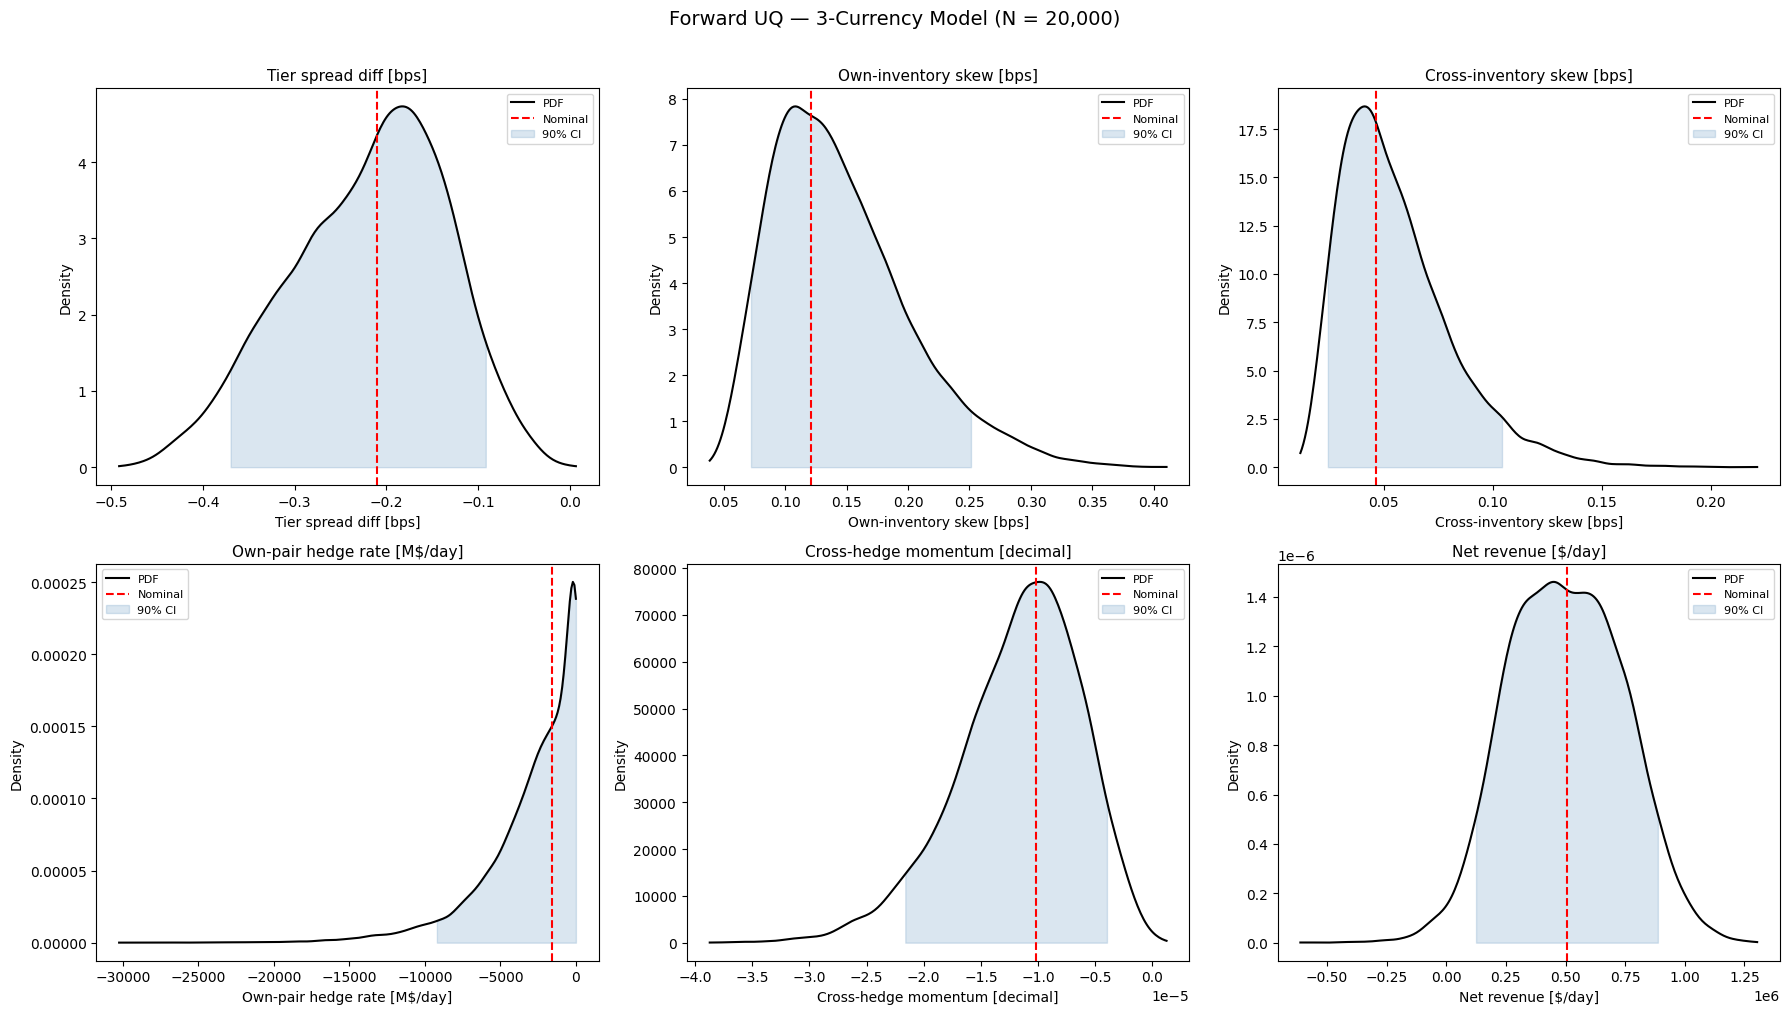

Saved: report/figures/fig_sa_forward_uq.pdf


In [78]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for q in range(N_QOIS):
    row = q // 3
    col = q % 3
    ax = axes[row, col]
    data = fwd_qois[:, q]

    # KDE with Silverman bandwidth
    kde = gaussian_kde(data, bw_method='silverman')
    x_grid = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_grid, kde(x_grid), 'k-', linewidth=1.5, label='PDF')
    ax.axvline(nominal_qois[q], color='r', linestyle='--', linewidth=1.5, label='Nominal')

    # Shade 90% CI
    p5, p95 = np.percentile(data, [5, 95])
    mask = (x_grid >= p5) & (x_grid <= p95)
    ax.fill_between(x_grid[mask], kde(x_grid[mask]), alpha=0.2, color='steelblue', label='90% CI')

    ax.set_xlabel(QOI_NAMES[q])
    ax.set_ylabel('Density')
    ax.set_title(QOI_NAMES[q], fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle(f'Forward UQ — 3-Currency Model (N = {N_FWD:,})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('report/figures/fig_sa_forward_uq.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: report/figures/fig_sa_forward_uq.pdf")